# LeNet-5 Architecture Implementation

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# Indica classe para informar que esse é o modelo de rede Neural, neste caso o nome é LeNet5
class LeNet5(nn.Module):    
    def __init__(self, num_classes=10):
        super(LeNet5, self).__init__()
        # C1: 1 canal de imagem de entrada, 6 canais de saída, convolução quadrada 5x5
        # Adicionamos padding=2 para lidar com imagens MNIST 28x28 como a entrada original 32x32
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, stride=1, padding=2)
        # S2: Camada de pooling médio com kernel 2x2 e stride 2
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C3: 6 canais de entrada, 16 canais de saída, convolução quadrada 5x5
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        # S4: Camada de pooling médio com kernel 2x2 e stride 2
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # C5: 16 canais de entrada, 120 canais de saída, convolução quadrada 5x5
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5)
        # F6: Camada totalmente conectada
        self.fc1 = nn.Linear(120, 84)
        # Nível de saída: Camada totalmente conectada
        self.fc2 = nn.Linear(84, num_classes)

    def forward(self, x):
        # Aplicar C1 seguido de ativação ReLU e pooling 2×2
        x = self.pool1(F.relu(self.conv1(x)))
        # Aplicar C3 seguido de ativação ReLU e pooling 2×2
        x = self.pool2(F.relu(self.conv2(x)))
        # Aplicar C5 seguido de ativação ReLU
        x = F.relu(self.conv3(x))
        # Achatar a saída para as camadas totalmente conectadas
        x = x.view(x.size(0), -1)
        # Aplicar F7 seguido de ativação ReLU
        x = F.relu(self.fc1(x))
        # Camada de saída final
        x = self.fc2(x)
        return x


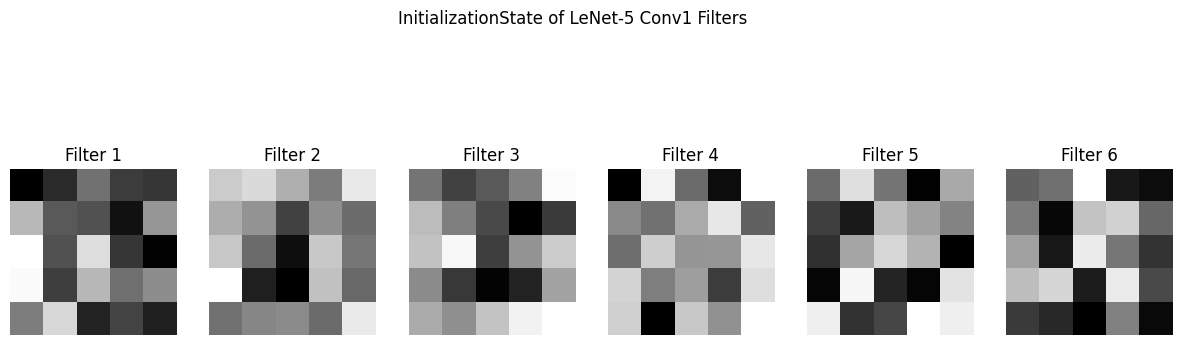

In [2]:
import matplotlib.pyplot as plt

# Instanciar o modelo
model = LeNet5(num_classes=10)

# Extrair filtros da primeira camada convolucional
filters = model.conv1.weight.detach()

# Plotando os filtros
fig, axes, = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    # Filtros de convolução padrão têm profundidade (canais); pegamos a primeira fatia
    # Como MNIST é em escala de cinza, input_channels = 1
    ax.imshow(filters[i, 0], cmap='gray')
    ax.set_title(f'Filter {i+1}')
    ax.axis('off')

plt.suptitle('InitializationState of LeNet-5 Conv1 Filters')
plt.show()

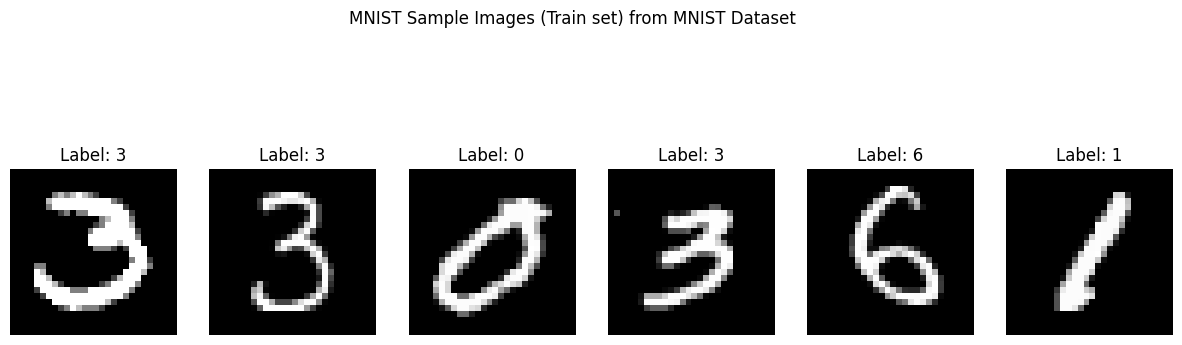

In [3]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Definir transformação para converter imagens em tensores
transform = transforms.Compose([transforms.ToTensor()])

# Baixar e carregar dados de treinamento
mnist_train = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
train_loader = DataLoader(mnist_train, batch_size=6, shuffle=True)

# Obter algumas imagens aleatórias
datailter = iter(train_loader)
images, labels = next(datailter)

# Plotar imagens
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i, ax in enumerate(axes):
    ax.imshow(images[i].squeeze(), cmap="gray")
    ax.set_title(f'Label: {(labels[i].item())}')
    ax.axis("off")

plt.suptitle("MNIST Sample Images (Train set) from MNIST Dataset")
plt.show()


In [4]:
# Loop de treinamento para LeNet-5 no MNIST
import torch.optim as optim

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")   # Verifica se você tem uma GPU dedicada ou se vai rodar no modo cuda do próprio sistema
model.to(device)

# Hiperparâmetros
learning_rate = 0.001   # Velocidade que ele vai observar
batch_size = 64         # Quantidade de imagens que ele vai analisar
num_epochs = 5          # Quantidade de vezes que vai passar pelo nosso dataset (5.000)

# Atualizar DataLoader com batch size maior para treinamento
train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True)   # Facilita o processo de ordem de imagens

# Loss e otimizador
criterion = nn.CrossEntropyLoss()   # Comparando com o "gabarito" do MNIST em DATASET
optimizer = optim.Adam(model.parameters(), lr=learning_rate)    # Informa como ela vai fazer a correção da Rede Neural,  (otimizador = Adam)

# Loop de treinamento
print(f'Treinando em {device}...')
model.train()

for epoch in range(num_epochs):
    runnin_loss = 0.0
    for i, (images, labels) in enumerate(train_loader): # Carrega as 64 imagens por vez
        images = images.to(device)  # Imagens
        labels = labels.to(device)  # Respostas corretas

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward e otimizar
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()    # Faz o aprendizado da Rede Neural

        runnin_loss += loss.item()
        if (i+1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {runnin_loss / (i+1):.4f}')

print("Training finished!")

Treinando em cpu...
Epoch [1/5], Step [100/938], Loss: 1.3139
Epoch [1/5], Step [200/938], Loss: 0.8654
Epoch [1/5], Step [300/938], Loss: 0.6734
Epoch [1/5], Step [400/938], Loss: 0.5614
Epoch [1/5], Step [500/938], Loss: 0.4838
Epoch [1/5], Step [600/938], Loss: 0.4299
Epoch [1/5], Step [700/938], Loss: 0.3899
Epoch [1/5], Step [800/938], Loss: 0.3559
Epoch [1/5], Step [900/938], Loss: 0.3294
Epoch [2/5], Step [100/938], Loss: 0.0952
Epoch [2/5], Step [200/938], Loss: 0.0929
Epoch [2/5], Step [300/938], Loss: 0.0889
Epoch [2/5], Step [400/938], Loss: 0.0866
Epoch [2/5], Step [500/938], Loss: 0.0855
Epoch [2/5], Step [600/938], Loss: 0.0863
Epoch [2/5], Step [700/938], Loss: 0.0866
Epoch [2/5], Step [800/938], Loss: 0.0846
Epoch [2/5], Step [900/938], Loss: 0.0825
Epoch [3/5], Step [100/938], Loss: 0.0483
Epoch [3/5], Step [200/938], Loss: 0.0542
Epoch [3/5], Step [300/938], Loss: 0.0564
Epoch [3/5], Step [400/938], Loss: 0.0573
Epoch [3/5], Step [500/938], Loss: 0.0584
Epoch [3/5], S

In [5]:
# Salvar o modelo treinado
torch.save(model.state_dict(), 'lenet5_mnist.pth')
print("Model saved to 'lenet5_mnist.pth'")

Model saved to 'lenet5_mnist.pth'


In [6]:
# Carregar o modelo treinado (exemplo)
# model = LeNet5(num_classes=10)  # Instanciar o modelo
# model.load_state_dict(torch.load('lenet5_mnist.pth'))
# model.to(device)
# model.eval()
# print("Modelo carregado de 'lenet5_mnist.pth'")

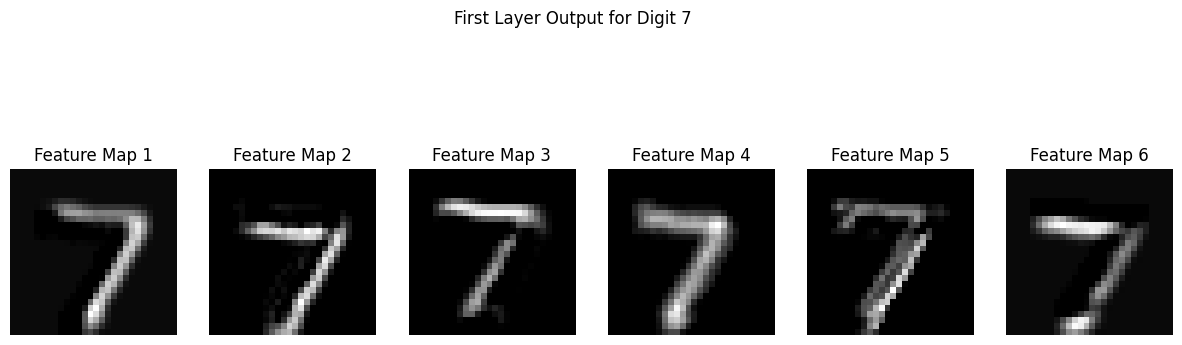

In [7]:
# Visualizar a saída da primeira camada convolucional
# Obter uma imagem de amostra do conjunto de teste
sample_image, sample_label = mnist_test[0]  # Primeira imagem de teste
sample_image = sample_image.unsqueeze(0).to(device)  # Adicionar dimensão de batch e mover para device

# Aplicar primeira camada conv (conv1 + relu)
with torch.no_grad():
    conv1_output = F.relu(model.conv1(sample_image))

# Mover para CPU para plotar
conv1_output = conv1_output.cpu().squeeze(0)  # Remover dimensão de batch

# Plotar os 6 mapas de features
fig, axes = plt.subplots(1, 6, figsize=(15, 5))
for i in range(6):
    axes[i].imshow(conv1_output[i], cmap='gray')
    axes[i].set_title(f'Feature Map {i+1}')
    axes[i].axis('off')

plt.suptitle(f'First Layer Output for Digit {sample_label}')
plt.show()

Test Loss: 0.0384
Accuracy on test set: 98.86%
Number of misclassified examples: 114


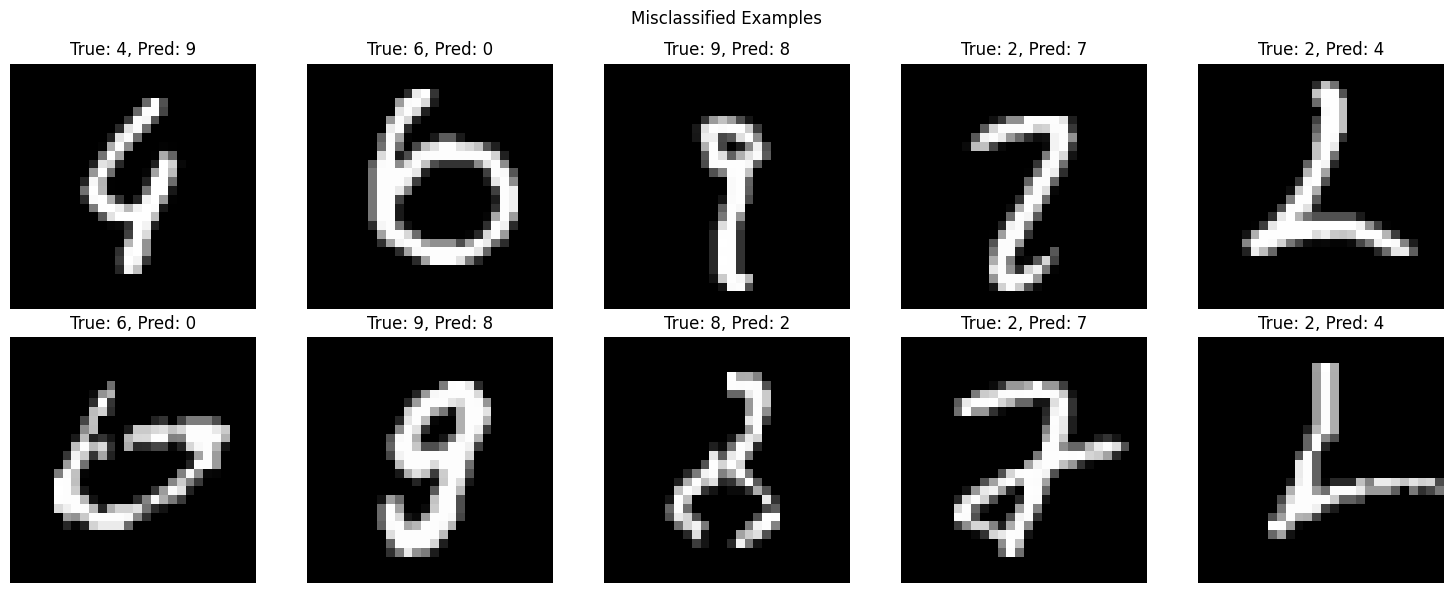

In [8]:
# Carregar conjunto de teste e avaliar performance do modelo
mnist_test = datasets.MNIST(root="./data", train=False, download=True, transform=transform)
test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False)

# Definir modelo para modo de avaliação
model.eval()

correct = 0
total = 0
test_loss = 0.0
misclassified = []  # Lista para armazenar exemplos classificados incorretamente

# Não é necessário cálculo de gradiente durante avaliação
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)   # Manda ela rodar na nossa GPU

        outputs = model(images)
        loss = criterion(outputs, labels)
        test_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)   # predicted é o número informado pela IA
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Coletar exemplos classificados incorretamente
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                misclassified.append((images[i].cpu(), labels[i].cpu(), predicted[i].cpu()))

accuracy = 100 * correct / total
avg_test_loss = test_loss / len(test_loader)

print(f'Test Loss: {avg_test_loss:.4f}')
print(f'Accuracy on test set: {accuracy:.2f}%')
print(f'Number of misclassified examples: {len(misclassified)}')

# Plotar alguns exemplos classificados incorretamente
if misclassified:
    num_to_show = min(10, len(misclassified))
    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()
    for i in range(num_to_show):
        img, true_label, pred_label = misclassified[i]
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].set_title(f'True: {true_label.item()}, Pred: {pred_label.item()}')
        axes[i].axis('off')
    plt.suptitle('Misclassified Examples')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified examples found!")

# Salvando o Modelo

Melhor prática no PyTorch é salvar o "state_dict" que contém apenas os parâmetros aprendidos

In [9]:
import os

# Criar diretório 'weights' se não existir
os.makedirs('weights', exist_ok=True)

# Definir caminho de salvamento
PATH = './weights/lenet5_mnist.pth'

torch.save(model.state_dict(), PATH)
print(f"Modelo salvo em {PATH}")

Modelo salvo em ./weights/lenet5_mnist.pth
